**Řešíme 2D úlohu konekce:**
$$\begin{align*}
    \frac{\partial u}{\partial t} + \beta \frac{\partial u}{\partial x} &= 0, \quad x \in [0, 2\pi],\,t\in[0, 1] \\
    u(x, 0) &= \sin(x) + \cos(x) \\
    u(0, t) &= u(2\pi, t),
\end{align*}$$
kde $\beta > 0$ je koeficient konvekce. Analytické řešení je
$$\begin{equation*}
    u(x, t) = \sin(x - \beta t) + \cos(x - \beta t).
\end{equation*}$$
Níže natrénujeme model řešící tuto úlohu, a poté jej porovnáme se správným řešením úlohy.
První trénování proběhne bez použití fourier features, druhé s jejich použitím.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Zakladni importy
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
import sys

In [ ]:
# Import vlastnich modulu
sys.path.append("../..")
import src.data.cube_domain as cb
import src.models.mlp_model as mm
from src import train
from src import calculus as calc
from src import utils

In [4]:
# Volba spravneho device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# Definice ztratove funkce

BETA = 30 # BETA -- konstanta konvekce

# BETA neni argument funkce, protoze kazdy trenovaci algoritmus ocekava, ze 
# jako argument jen a pouze model a domena.
def loss_fn(model: torch.nn.Module, domain: cb.CubeDomain) -> torch.Tensor:
    _, u_x, u_t = calc.compute_derivatives_2d(model, domain.interior)
    pde_loss = torch.mean((u_t + BETA * u_x)**2)

    u_bottom = model(domain.sides[1][0])
    left_loss = torch.mean((u_bottom - torch.sin(domain.sides[1][0][:, 0:1]) 
                            - torch.cos(domain.sides[1][0][:, 0:1]))**2)

    u_left = model(domain.sides[0][0])
    u_right = model(domain.sides[0][1])
    top_bot_loss = torch.mean((u_left - u_right)**2)

    return [pde_loss, left_loss, top_bot_loss]

def exact_solution(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(x[:, 0:1] - BETA * x[:, 1:2]) + torch.cos(x[:, 0:1] - BETA * x[:, 1:2])

def l2_loss(model: torch.nn.Module, domain: cb.CubeDomain) -> torch.Tensor:
    return [calc.L2_norm(model, exact_solution, 2, domain.ctx.u_bounds, domain.ctx.l_bounds, device, 50)]

In [6]:
# Definice modelu, domeny problemu a optimalizatoru
# prostor x je prvni (nulta) promenna,
# cas t je druha (prvni) promenna
domain_ctx = cb.CubeContext(
    dim=2,
    l_bounds=[0, 0],
    u_bounds=[2*np.pi, 1],
    N_int=2_000,
    N_sides=[(100, 100), (100, 100)],
    device=device,
    mirror_left_right=[True, False]
)

model_ctx = mm.ModelContext(
    input_dim=2,
    output_dim=1,
    layer=[64, 64, 128],
    u_bounds=domain_ctx.u_bounds,
    l_bounds=domain_ctx.l_bounds,
    fourier_features=False,
    normalize=False
)

model = mm.MLPModel(model_ctx).to(device)
domain = cb.CubeDomain(domain_ctx)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
scheduler = ReduceLROnPlateau(optimizer=optimizer, factor=0.5, patience=300)

In [7]:
# Trenujeme algoritmus a ukladame hodnoty ztraty
train_ctx = train.TrainingContext(
    model=model,
    optimizer=optimizer,
    domain=domain,
    loss_fn=loss_fn,
    epochs=10_000,
    monitor_lr=True,
    resample_freq=100
)

total_loss_values, component_loss_values = train.train_switch_to_lbfgs(train_ctx, epochs_with_lbfgs=500, lbfgs_lr=0.08)

Loss at epoch 1 is: 1.1114649772644043. Current learing rate: 0.0005 
Loss at epoch 100 is: 1.0373269319534302. Current learing rate: 0.0005 
Loss at epoch 200 is: 0.9348574280738831. Current learing rate: 0.0005 
Loss at epoch 300 is: 1.018046498298645. Current learing rate: 0.0005 
Loss at epoch 400 is: 0.9733355045318604. Current learing rate: 0.0005 
Loss at epoch 500 is: 0.934240460395813. Current learing rate: 0.0005 
Loss at epoch 600 is: 0.6942867040634155. Current learing rate: 0.0005 
Loss at epoch 700 is: 0.3653710186481476. Current learing rate: 0.0005 


KeyboardInterrupt: 

In [ ]:
train_ctx.epochs = 10_000
model_ctx.normalize = True
model_norm = mm.MLPModel(model_ctx).to(device)
train_ctx.model = model_norm
train_ctx.optimizer = torch.optim.Adam(train_ctx.model.parameters(), lr=0.0005)

loss_values_norm, comp_loss_values_norm = train.train_switch_to_lbfgs(train_ctx, lbfgs_lr=0.1)

Loss at epoch 1 is: 0.9850561022758484. Current learing rate: 0.0005 
Loss at epoch 100 is: 0.8613371849060059. Current learing rate: 0.0005 
Loss at epoch 200 is: 0.9109891057014465. Current learing rate: 0.0005 
Loss at epoch 300 is: 0.868066132068634. Current learing rate: 0.0005 
Loss at epoch 400 is: 0.6264830231666565. Current learing rate: 0.0005 
Loss at epoch 500 is: 0.4049181044101715. Current learing rate: 0.0005 
Loss at epoch 600 is: 0.3336024880409241. Current learing rate: 0.0005 
Loss at epoch 700 is: 0.3603197932243347. Current learing rate: 0.0005 
Loss at epoch 800 is: 0.28535255789756775. Current learing rate: 0.0005 
Loss at epoch 900 is: 0.22613933682441711. Current learing rate: 0.0005 
Loss at epoch 1000 is: 0.09624697268009186. Current learing rate: 0.0005 
Loss at epoch 1100 is: 0.02034343220293522. Current learing rate: 0.0005 
Loss at epoch 1200 is: 0.02524295449256897. Current learing rate: 0.0005 
Loss at epoch 1300 is: 0.008726745843887329. Current learin

In [ ]:
# A nyni s fourier features
model_ctx.fourier_features = 'Timeless'
model_ctx.fourier_frequencies = 128
model_ctx.fourier_scale = 10.0 # arbitrarni hodnoty
model_ctx.normalize = False

model_ff = mm.MLPModel(model_ctx).to(device)
optimizer_ff = torch.optim.Adam(model_ff.parameters(), lr=0.0001)
scheduler_ff = ReduceLROnPlateau(optimizer=optimizer_ff, factor=0.75, patience=200)

In [ ]:
# Trenujeme algoritmus a ukladame hodnoty ztraty
train_ctx.model = model_ff
train_ctx.optimizer = optimizer_ff
train_ctx.scheduler = None
train_ctx.epochs = 10_000

total_loss_values_ff, component_loss_values_ff = train.train_switch_to_lbfgs(train_ctx, epochs_with_lbfgs=500, lbfgs_lr=0.1)

Loss at epoch 1 is: 6687.23291015625. Current learing rate: 0.0001 
Loss at epoch 100 is: 28.112972259521484. Current learing rate: 0.0001 
Loss at epoch 200 is: 12.441834449768066. Current learing rate: 0.0001 
Loss at epoch 300 is: 8.180022239685059. Current learing rate: 0.0001 
Loss at epoch 400 is: 6.775705337524414. Current learing rate: 0.0001 
Loss at epoch 500 is: 5.218999862670898. Current learing rate: 0.0001 
Loss at epoch 600 is: 4.335216522216797. Current learing rate: 0.0001 
Loss at epoch 700 is: 3.574685573577881. Current learing rate: 0.0001 
Loss at epoch 800 is: 3.277865171432495. Current learing rate: 0.0001 
Loss at epoch 900 is: 3.109034299850464. Current learing rate: 0.0001 
Loss at epoch 1000 is: 2.824791431427002. Current learing rate: 0.0001 
Loss at epoch 1100 is: 2.797642230987549. Current learing rate: 0.0001 
Loss at epoch 1200 is: 2.4976985454559326. Current learing rate: 0.0001 
Loss at epoch 1300 is: 2.1126344203948975. Current learing rate: 0.0001 
L

In [ ]:
betas = [0.1, 1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0, 22.0, 24.0, 26.0, 28.0, 30.0]
train_ctx.epochs = 300
model_ctx.normalize = False
model_ctx.fourier_features = ''
model_curr = mm.MLPModel(model_ctx).to(device)
train_ctx.model = model_curr
train_ctx.optimizer = torch.optim.Adam(train_ctx.model.parameters(), lr=0.001)

loss_values_curr = []
comp_loss_values_curr = [[], [], []]

for BETA in betas:
    temp_loss_values_curr, temp_comp_loss_values_curr = train.train_switch_to_lbfgs(train_ctx, epochs_with_lbfgs=500, lbfgs_lr=0.1)
    loss_values_curr += temp_loss_values_curr
    for i, temp_com_loss in enumerate(temp_comp_loss_values_curr):
        comp_loss_values_curr[i] += temp_com_loss

Loss at epoch 1 is: 1.1218582391738892. Current learing rate: 0.001 
Loss at epoch 100 is: 0.04397007077932358. Current learing rate: 0.001 
Loss at epoch 200 is: 0.02698385715484619. Current learing rate: 0.001 
Loss at epoch 300 is: 0.01769939251244068. Current learing rate: 0.001 
Switching to LBFGS
Loss at lbfgs-epoch 100 is: 0.00022285670274868608
Loss at lbfgs-epoch 200 is: 0.0002244912611786276
Loss at lbfgs-epoch 300 is: 0.00018153368728235364
Loss at lbfgs-epoch 400 is: 0.00012143853382440284
Loss at lbfgs-epoch 500 is: 0.0001299474242841825
Loss at epoch 1 is: 0.8052414655685425. Current learing rate: 0.001 
Loss at epoch 100 is: 0.714652955532074. Current learing rate: 0.001 
Loss at epoch 200 is: 0.48542946577072144. Current learing rate: 0.001 
Loss at epoch 300 is: 0.2112613469362259. Current learing rate: 0.001 
Switching to LBFGS
Loss at lbfgs-epoch 100 is: 9.558466990711167e-05
Loss at lbfgs-epoch 200 is: 6.336691876640543e-05
Loss at lbfgs-epoch 300 is: 5.804953616461

KeyboardInterrupt: 

In [ ]:
model_ctx.normalize = True
model_nor_curr = mm.MLPModel(model_ctx).to(device)
train_ctx.model = model_nor_curr
train_ctx.optimizer = torch.optim.Adam(train_ctx.model.parameters(), lr=0.001)

loss_values_nor_curr = []
comp_loss_values_nor_curr = [[], [], []]

for BETA in betas:
    temp_loss_values_nor_curr, temp_comp_loss_values_nor_curr = train.train_switch_to_lbfgs(train_ctx, epochs_with_lbfgs=500, lbfgs_lr=0.1)
    loss_values_nor_curr += temp_loss_values_nor_curr
    for i, temp_comp_loss in enumerate(temp_comp_loss_values_nor_curr):
        comp_loss_values_nor_curr[i] += temp_com_loss

Loss at epoch 1 is: 1.033531665802002. Current learing rate: 0.001 
Loss at epoch 100 is: 0.08048354834318161. Current learing rate: 0.001 
Loss at epoch 200 is: 0.011808592826128006. Current learing rate: 0.001 
Loss at epoch 300 is: 0.010009970515966415. Current learing rate: 0.001 
Switching to LBFGS
Loss at lbfgs-epoch 100 is: 1.71714218595298e-05
Loss at lbfgs-epoch 200 is: 5.866939318366349e-06
Loss at lbfgs-epoch 300 is: 5.75426702198456e-06
Loss at lbfgs-epoch 400 is: 5.19089098816039e-06
Loss at lbfgs-epoch 500 is: 6.281984497036319e-06
Loss at epoch 1 is: 0.8139796257019043. Current learing rate: 0.001 
Loss at epoch 100 is: 0.006077105179429054. Current learing rate: 0.001 
Loss at epoch 200 is: 0.001824068371206522. Current learing rate: 0.001 
Loss at epoch 300 is: 0.0007193208439275622. Current learing rate: 0.001 
Switching to LBFGS
Loss at lbfgs-epoch 100 is: 6.122428658272838e-06
Loss at lbfgs-epoch 200 is: 2.3991094622033415e-06
Loss at lbfgs-epoch 300 is: 2.018118038

In [11]:
model_ctx.normalize = True
train_ctx.loss_fn = l2_loss
train_ctx.model = mm.MLPModel(model_ctx).to(device)
train_ctx.optimizer = torch.optim.Adam(train_ctx.model.parameters(), lr=0.001)
train_ctx.monitor_gradient = True
train_ctx.epochs=30_000

loss_capability, _ = train.train_switch_to_lbfgs(train_ctx)

Loss at epoch 1 is: 2.5275626182556152. Total gradient norm: 0.5493407980429831 Current learing rate: 0.001 
Loss at epoch 100 is: 2.4968442916870117. Total gradient norm: 0.005661598980265014 Current learing rate: 0.001 
Loss at epoch 200 is: 2.48986554145813. Total gradient norm: 0.12353639114910818 Current learing rate: 0.001 
Loss at epoch 300 is: 2.4786150455474854. Total gradient norm: 1.1453037235662658 Current learing rate: 0.001 
Loss at epoch 400 is: 2.471682071685791. Total gradient norm: 2.2052584137179756 Current learing rate: 0.001 
Loss at epoch 500 is: 2.4625906944274902. Total gradient norm: 0.13586514005925612 Current learing rate: 0.001 
Loss at epoch 600 is: 2.461770534515381. Total gradient norm: 0.3398082812839706 Current learing rate: 0.001 
Loss at epoch 700 is: 2.4942476749420166. Total gradient norm: 4.923417938380475 Current learing rate: 0.001 
Loss at epoch 800 is: 2.459062099456787. Total gradient norm: 0.03750260225003916 Current learing rate: 0.001 
Loss

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/../src/utils.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


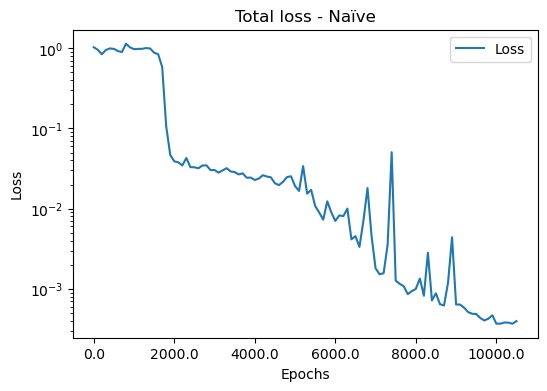

NameError: name 'loss_values_norm' is not defined

In [ ]:
# Vykresleni ztraty
plot_ctx = utils.PlotContext(
    l_bounds = [0, 0],
    u_bounds=[2*np.pi, 0.1],
    patches=[],
    device=device,
    vmin=-1.3,
    vmax=1.3,
    N=100,
    save_img=False,
    x_label='Epochs',
    y_label='Loss',
)

plot_ctx.titles = ['Total loss - Naïve']
utils.plot_loss_values({"Loss": total_loss_values}, plot_ctx)

plot_ctx.titles = ['Total loss - Normalized']
utils.plot_loss_values({"Loss": loss_values_norm}, plot_ctx)

plot_ctx.titles = ['Total loss - FF']
utils.plot_loss_values({"Loss": total_loss_values_ff}, plot_ctx)

plot_ctx.titles = ['Total loss - Curriculum']
utils.plot_loss_values({"Loss": loss_values_curr}, plot_ctx)

plot_ctx.titles = ['Total loss - Normalized + Curriculum']
utils.plot_loss_values({"Loss": loss_values_nor_curr}, plot_ctx)

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/../src/utils.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


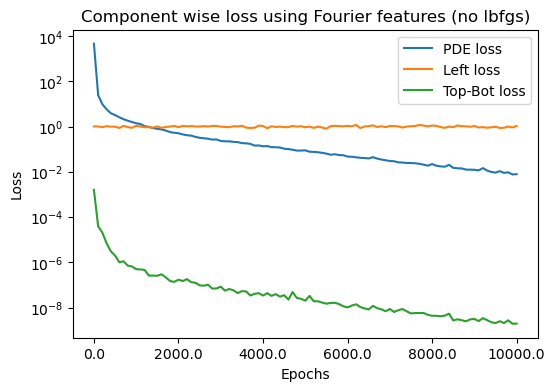

In [ ]:
plot_ctx.titles = ['Total loss using Fourier features']
plot_ctx.titles = ['Component wise loss using Fourier features (no lbfgs)']
utils.plot_loss_values({"PDE loss": component_loss_values_ff[0],
                        "Left loss": component_loss_values_ff[1],
                        "Top-Bot loss": component_loss_values_ff[2]}, plot_ctx)

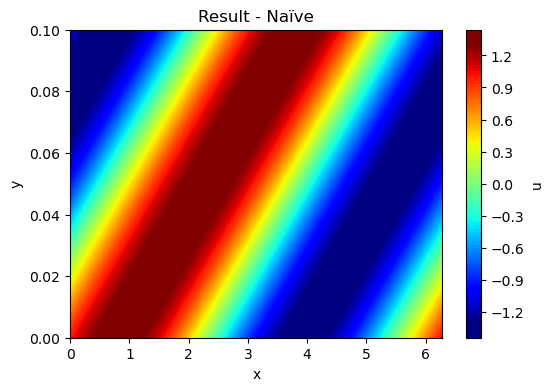

NameError: name 'model_ff' is not defined

In [ ]:
# Vykresleni priblizneho reseni (minus interpolace)
plot_ctx.x_label = 'x'
plot_ctx.y_label = 'y'
plot_ctx.function_names = ['u', 'u']
plot_ctx.figsize = (6, 4)
plot_ctx.fontsize = 12

plot_ctx.titles = ['Result - Naïve']
utils.plot_function_on_2d_cube([model], plot_ctx)

plot_ctx.titles = ['Result - FF']
utils.plot_function_on_2d_cube([model_ff], plot_ctx)

plot_ctx.titles = ['Result - Curriculum']
utils.plot_function_on_2d_cube([model_curr], plot_ctx)

plot_ctx.titles = ['Result - Normalized']
utils.plot_function_on_2d_cube([model_norm], plot_ctx)

plot_ctx.titles = ['Result - Normalized + Curriculum']
utils.plot_function_on_2d_cube([model_nor_curr], plot_ctx)

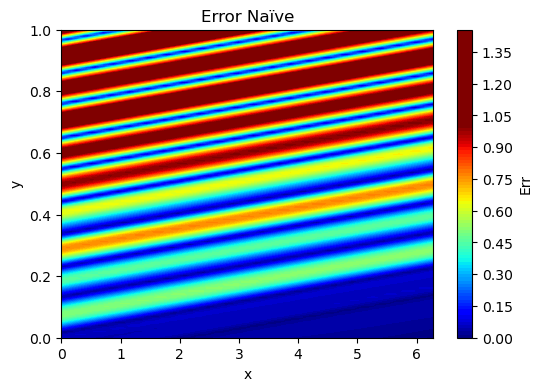

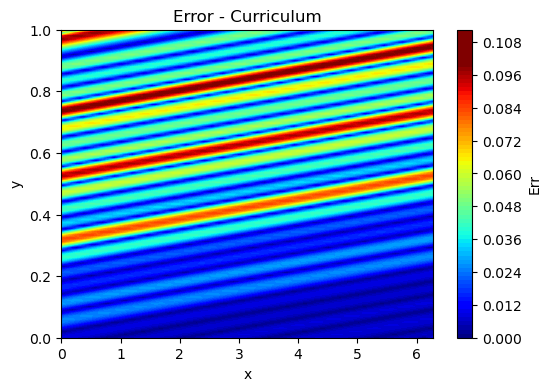

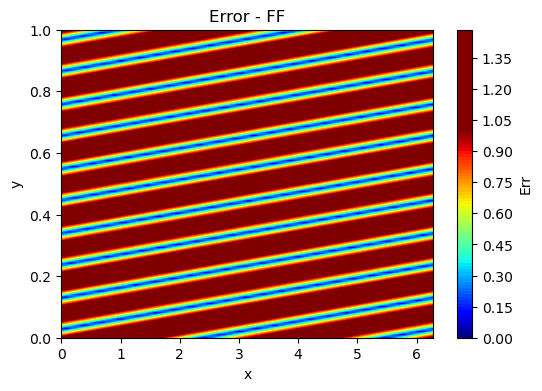

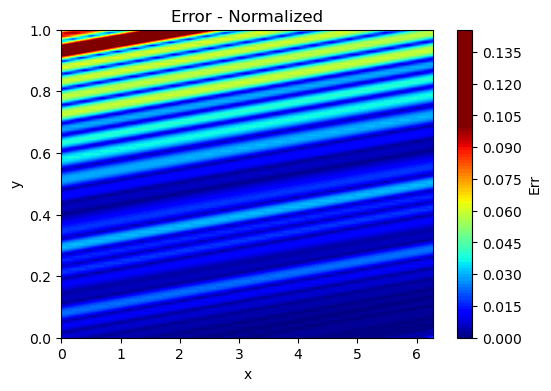

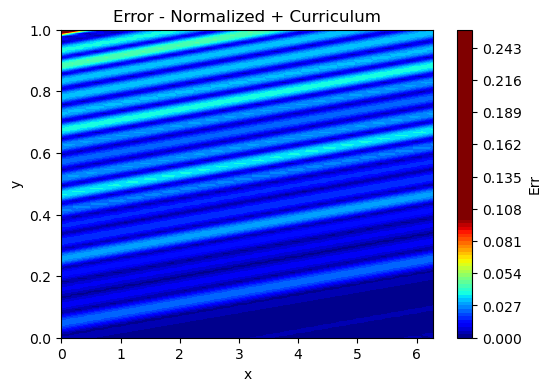

In [ ]:
plot_ctx.titles = ['Error Naïve']
plot_ctx.function_names = ['Err']
plot_ctx.figsize = (6, 4)
plot_ctx.fontsize = 12
plot_ctx.vmax=1
plot_ctx.vmin=0.0

utils.plot_function_on_2d_cube([lambda x: torch.abs(model(x) - exact_solution(x))], plot_ctx)

plot_ctx.titles = ['Error - Curriculum']
plot_ctx.vmax=0.1
plot_ctx.vmin=0.0
utils.plot_function_on_2d_cube([lambda x: torch.abs(model_curr(x) - exact_solution(x))], plot_ctx)

plot_ctx.titles = ['Error - FF']
plot_ctx.vmax=1
plot_ctx.vmin=0.0
utils.plot_function_on_2d_cube([lambda x: torch.abs(model_ff(x) - exact_solution(x))], plot_ctx)

plot_ctx.titles = ['Error - Normalized']
plot_ctx.vmax=0.1
plot_ctx.vmin=0.0
utils.plot_function_on_2d_cube([lambda x: torch.abs(model_norm(x) - exact_solution(x))], plot_ctx)

plot_ctx.titles = ['Error - Normalized + Curriculum']
plot_ctx.vmax=0.1
plot_ctx.vmin=0.0
utils.plot_function_on_2d_cube([lambda x: torch.abs(model_nor_curr(x) - exact_solution(x))], plot_ctx)

In [ ]:
torch.cuda.empty_cache()


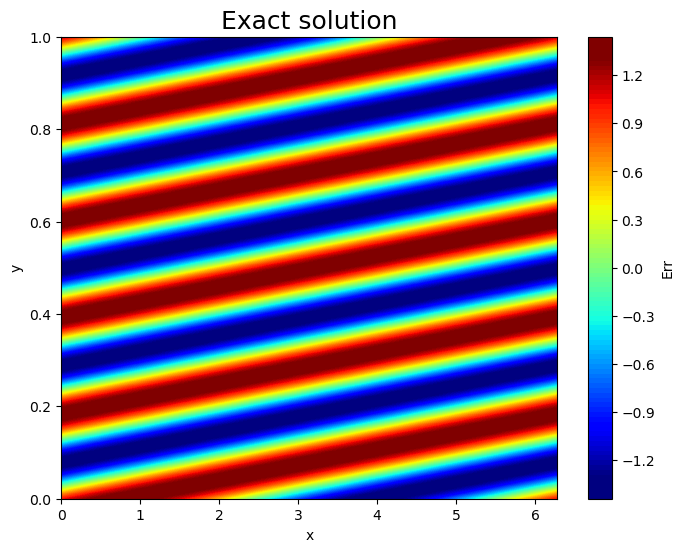

In [ ]:
# Vykresleni skutecneho reseni (minus interpolace)
BETA = 30
plot_ctx.titles = ['Exact solution']
plot_ctx.vmin=-1.3
plot_ctx.vmax=1.3
plot_ctx.figsize = (8, 6)

utils.plot_function_on_2d_cube([exact_solution], plot_ctx)

In [ ]:
# a na zaver porovnani pomoci L2 normy
norm = calc.L2_norm(model, exact_solution, 2, domain_ctx.u_bounds, domain_ctx.l_bounds, device, n=100)
print(f"L2 chyba naivni {norm}")

norm_ff = calc.L2_norm(model_ff, exact_solution, 2, domain_ctx.u_bounds, domain_ctx.l_bounds, device, n=100)
print(f"L2 chyba s ff je {norm_ff}")

norm_curr = calc.L2_norm(model_curr, exact_solution, 2, domain_ctx.u_bounds, domain_ctx.l_bounds, device, n=100)
print(f"L2 chyba curriculum je {norm_curr}")

norm_norm = calc.L2_norm(model_norm, exact_solution, 2, domain_ctx.u_bounds, domain_ctx.l_bounds, device, n=100)
print(f"L2 chyba normovane site je {norm_norm}")

norm_nor_curr = calc.L2_norm(model_nor_curr, exact_solution, 2, domain_ctx.u_bounds, domain_ctx.l_bounds, device, n=100)
print(f"L2 chyba normovane site s Curriculum Learningem je {norm_nor_curr}")

L2 chyba naivni 1.5580252408981323
L2 chyba s ff je 2.5109658241271973
L2 chyba curriculum je 0.09778940677642822
L2 chyba normovane site je 0.06871430575847626
L2 chyba normovane site s Curriculum Learningem je 0.04593940079212189
